In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from collections import defaultdict
import copy
import os
import pprint

import hydra
from omegaconf import OmegaConf
from einops import rearrange
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_theme(style='whitegrid', font_scale=1.3, palette=sns.color_palette('Set2'),)
import sqlalchemy as sa

from conf import conf
from dafm import datasets, models, plots, utils, plot_utils

In [3]:
alt_ids = {
    ('3c2kp8qq', r'FM-TF (H300, Gau)'): {},
    # ('7wbiwugd', r'FM-TF ($\alpha=0.0$, $\sigma_\epsilon=0.05$)'): {},
    # ('vndtd2t3', r'FM-TF ($\alpha=0.0$, $\sigma_\epsilon=0.1$)'): {},
    # ('jp0uyobi', r'FM-TF ($\alpha=0.0$, $\sigma_\epsilon=0.5$)'): {},
    # ('qf40s01f', r'FM-TF ($\alpha=1.01$, $\sigma_\epsilon=0.0$)'): {},
    # ('6zsipstg', r'FM-TF ($\alpha=1.01$, $\sigma_\epsilon=0.05$)'): {},
    # ('6ak4pms4', r'FM-TF ($\alpha=1.01$, $\sigma_\epsilon=0.1$)'): {},
    # ('du4ktgor', r'FM-TF ($\alpha=1.01$, $\sigma_\epsilon=0.5$)'): {},
    # ('3azmqj8h', r'FM-TF ($\alpha=1.05$, $\sigma_\epsilon=0.0$)'): {},
    # ('mgejwujq', r'FM-TF ($\alpha=1.05$, $\sigma_\epsilon=0.05$)'): {},
    # ('8g502jvo', r'FM-TF ($\alpha=1.05$, $\sigma_\epsilon=0.1$)'): {},
    # ('9xhdrnn6', r'FM-TF ($\alpha=1.05$, $\sigma_\epsilon=0.5$)'): {},
    # ('e96jehhu', r'FM-TF ($\alpha=1.1$, $\sigma_\epsilon=0.0$)'): {},
    # ('02y8pirf', r'FM-TF ($\alpha=1.1$, $\sigma_\epsilon=0.05$)'): {},
    # ('pgm8cm0m', r'FM-TF ($\alpha=1.1$, $\sigma_\epsilon=0.1$)'): {},
    # ('jvzfo18f', r'FM-TF ($\alpha=1.1$, $\sigma_\epsilon=0.5$)'): {},
    # ('uhn6wquo', r'FM-TF ($\alpha=1.15$, $\sigma_\epsilon=0.0$)'): {},
    # ('g5aubg4p', r'FM-TF ($\alpha=1.15$, $\sigma_\epsilon=0.05$)'): {},
    # ('fs43c1uu', r'FM-TF ($\alpha=1.15$, $\sigma_\epsilon=0.1$)'): {},
    # ('j7zz8ff8', r'FM-TF ($\alpha=1.15$, $\sigma_\epsilon=0.5$)'): {},
    # ('y1do823b', r'FM-TF ($\alpha=1.2$, $\sigma_\epsilon=0.0$)'): {},
    # ('veamljn3', r'FM-TF ($\alpha=1.2$, $\sigma_\epsilon=0.05$)'): {},
    # ('747qijk1', r'FM-TF ($\alpha=1.2$, $\sigma_\epsilon=0.1$)'): {},
    # ('tfidk90j', r'FM-TF ($\alpha=1.2$, $\sigma_\epsilon=0.5$)'): {},
}
label_to_alt_id = dict(map(reversed, alt_ids))
assert len(alt_ids) == len(label_to_alt_id), "Do two alt_id's have the same plot label?"

In [4]:
engine = conf.get_engine()
with conf.sa.orm.Session(engine) as db:
    cfgs = db.execute(sa.select(conf.Conf).where(conf.Conf.alt_id.in_([k[0] for k in alt_ids])))
    cfgs = {c.alt_id: c for (c,) in cfgs}
    cfgs = {k: {'cfg': cfgs[k[0]]} for k in alt_ids}
    pprint.pp(cfgs)

{('3c2kp8qq', 'FM-TF (H300, Gau)'): {'cfg': Conf(root_dir='/home/bhchen/Data-Assimilation-Flow-Matching',
                                                 out_dir='/home/out/dafm',
                                                 run_subdir='runs',
                                                 prediction_filename='trajectories.parquet',
                                                 device='cuda',
                                                 alt_id='3c2kp8qq',
                                                 rng_seed=2376999025,
                                                 fit=True,
                                                 id=25,
                                                 dataset=Lorenz96(predicted_state_count=10,
                                                                  time_step_count=2000,
                                                                  time_step_count_drop_first=1000,
                                                              

In [5]:
for v in cfgs.values():
    v['trajectories'] = pd.read_parquet(v['cfg'].run_dir/v['cfg'].prediction_filename)

In [6]:
dim = 1
for v in cfgs.values():
    v['trajectories'][f'predicted_state_mean_{dim}'] = v['trajectories'][v['trajectories'].columns[v['trajectories'].columns.str.contains(f'^predicted_state_[0-9]+_dim_{dim}$')]].mean(axis=1)

Methods found: ['FM-TF (H300, Gau)']


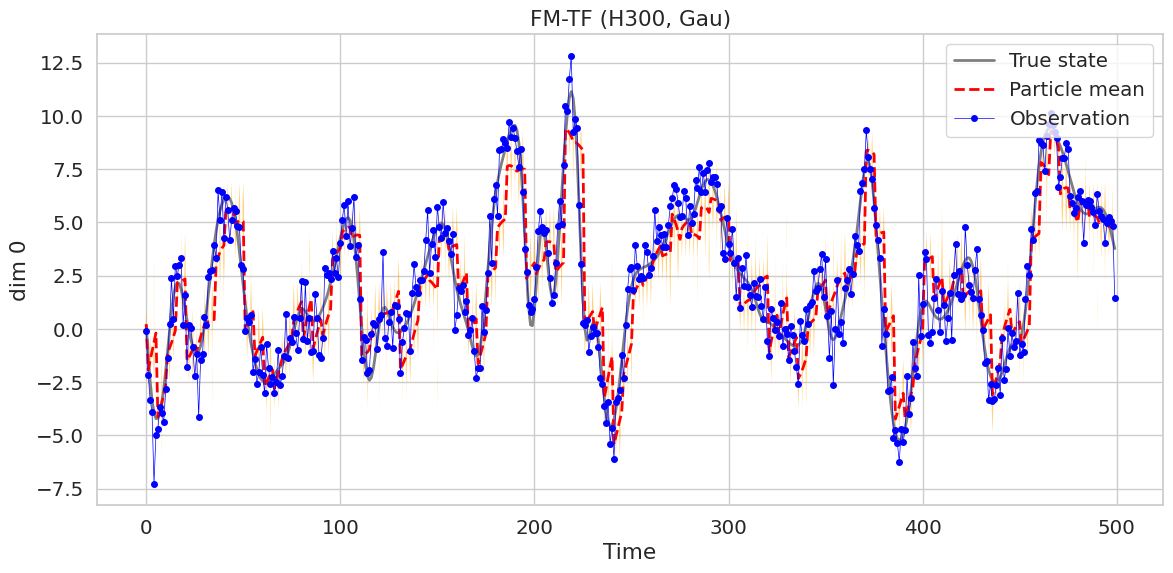

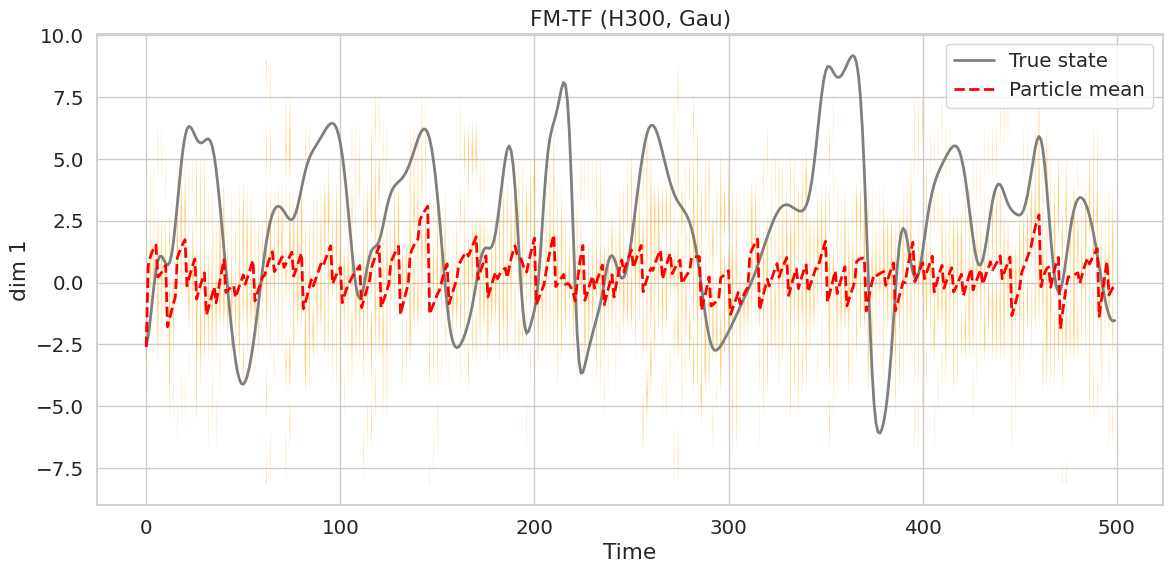

In [8]:
plot_utils.plot_particle_trajectories_with_histograms(
    cfgs,
    dims=[0,1],           # optionally limit to specific dims
    mode='width',            # 'width', 'color', or 'no' (means only lines)
    hist_step=2,          # plot every 2nd time slice
    max_time_steps=500,    # cap to 50 steps
)

In [9]:
(
    pd.concat([
        v['trajectories'] for v in cfgs.values()
    ], keys=[k for k in cfgs], names=['AltID', 'Model'])
    .groupby(level=['AltID', 'Model'])
    [[f'true_state_dim_{dim}', f'predicted_state_mean_{dim}']]
    .apply(lambda x: (x[f'true_state_dim_{dim}'] - x[f'predicted_state_mean_{dim}']).pow(2).mean(skipna=False)**(1/2))
    .rename('RMSE')
    .to_frame()
    .loc[[k[0] for k in cfgs]]
)

,,RMSE
AltID,Model,
3c2kp8qq,"FM-TF (H300, Gau)",4.141623


In [10]:
# columns = v['trajectories'].columns
# df_line_true_state = (
#     v['trajectories']
#     .melt(id_vars=['times'], var_name='StateAndDim', value_name='State', value_vars=columns[
#           (columns == f'true_state_dim_{dim}')
#     ])
#     .rename(columns={'times': 'Time'})
# )
# df_line = (
#     pd.concat([
#         v['trajectories'] for v in cfgs.values()
#     ], keys=[k[1] for k in cfgs], names=['Model'])
#     .reset_index()
#     .melt(id_vars=['Model', 'times'], var_name='StateAndDim', value_name='State', value_vars=columns[
#           (columns == f'predicted_state_mean_{dim}')
#     ])
#     .rename(columns={'times': 'Time'})
# )
# line_to_plot = ('true_state_dim_', 'True state')
# plot = (
#     sns.relplot(
#         data=df_line,
#         kind='line',
#         x='Time',
#         y='State',
#         row='Model',
#         hue='Model',
#         style='Model',
#         hue_order=[line_to_plot[1], *df_line['Model'].unique()],
#         palette=['tab:gray', *sns.color_palette()[:len(df_line['Model'].unique())]],
#         # markers=True,
#         aspect=3,
#         linewidth=2,
#         # hue_order=['true_state', 'predicted_state_mean'],
#     )
#     .set_titles('')
#     .set(ylim=(-8, 13))
# )
# plot.map(
#     sns.lineplot,
#     data=df_line_true_state,
#     x='Time',
#     y='State',
#     color='tab:gray',
# )
# sns.move_legend(
#     plot,
#     loc='upper center',
#     ncol=min(len(df_line['Model'].unique()), 2) + 1,
#     title='',
#     bbox_to_anchor=(.455, 1.06),
#     frameon=True,
#     fancybox=True,
# )
# for (row, col, hue), data in plot.facet_data():
#     ax = plot.axes[row][col]
#     ax.set_ylabel(label_to_alt_id[plot.row_names[row]])

In [11]:
# df = df_line[~df_line.isna().any(axis=1)]
# print('RMSE')
# print(df.transform(lambda x: x if x.name == 'Time' else x - df['True state']).pow(2).mean().pow(1/2).to_latex())
# print('MAE')
# print(df.transform(lambda x: x if x.name == 'Time' else x - df['True state']).abs().mean())
# (df.T - df['True state']).T.pow(2).sum()

In [12]:
# df_hist = (
#     pd.concat([
#         v['trajectories'] for v in cfgs.values()
#     ], keys=[k[1] for k in cfgs], names=['Model'])
#     .reset_index()
#     .melt(id_vars=['Model', 'times'], var_name='Source', value_name='State', value_vars=v['trajectories'].columns[v['trajectories'].columns.str.contains(f'^predicted_state_[0-9]+_dim_{dim}$')])
#     .rename(columns={'times': 'Time'})
# )#.melt(id_vars=['Time'], var_name='Source', value_name='State')
# line_to_plot = 'True state'
# plot = (
#     sns.displot(
#         data=df_hist,
#         x='Time',
#         y='State',
#         row='Model',
#         hue='Model',
#         hue_order=[line_to_plot, *df_hist['Model'].unique()],
#         palette=['tab:gray', *sns.color_palette()[:len(df_hist['Model'].unique())]],
#         bins=(v['trajectories']['times'], 101),
#         binwidth=(v['trajectories']['times'].diff().iloc[-1], None),
#         aspect=3,
#         binrange=(None, (-6, 12)),
#     )
#     .set_titles('')
#     # .set(xlim=(30, 35))
#     .set(xlim=(50, 55))
#     # .set(xticks=[])
# )
# plot.map(
#     sns.lineplot,
#     data=df_line_true_state,
#     x='Time',
#     y='State',
#     color='tab:gray',
# )
# sns.move_legend(
#     plot,
#     loc='upper center',
#     ncol=min(len(df_line['Model'].unique()), 2) + 1,
#     title='',
#     bbox_to_anchor=(.455, 1.07),
#     frameon=True,
#     fancybox=True,
# )
# for (row, col, hue), data in plot.facet_data():
#     ax = plot.axes[row][col]
#     ax.set_ylabel(label_to_alt_id[plot.row_names[row]])